# AmanLeb — Multilingual Transformer Classifier

This notebook develops the Transformer-based text classification stage of the AmanLeb project.

The classical machine learning baseline represented SMS messages using TF-IDF and classified them with class-weighted Logistic Regression. Although this approach achieved strong performance, TF-IDF represents text primarily through token-frequency statistics and does not explicitly model contextual relationships between words.

In this stage, a pretrained multilingual Transformer is fine-tuned to classify SMS messages into:

- `ham`
- `spam`
- `smishing`

The Transformer processes tokenized text using contextual representations and self-attention before passing the resulting representation to a classification head.

The main objectives are to:

1. Reuse the same training, validation, and test split used by the classical ML experiment.
2. Tokenize SMS messages using a pretrained multilingual tokenizer.
3. Fine-tune a pretrained multilingual Transformer for three-class classification.
4. Evaluate the model using the same metrics used for Logistic Regression.
5. Compare the Transformer against the classical ML baseline.
6. Investigate whether contextual representations improve generalization and minority-class detection.

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay
)

### 1.1 PyTorch and Device Check

In [ ]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Device: CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Load the Cleaned Dataset

In [ ]:
df = pd.read_csv("Dataset_5971_clean.csv")

print(df.shape)
df.head()

(5947, 5)


,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,no,no,no
1,ham,What's up? Do you want me to come online? If y...,no,no,no
2,ham,So u workin overtime nigpun?,no,no,no
3,ham,"Also sir, i sent you an email about how to log...",no,no,no
4,smishing,Please Stay At Home. To encourage the notion o...,no,no,no


In [ ]:
X = df["TEXT"]
y = df["LABEL"]

### 2.1 Reproduce the Classical ML Split

The same stratified 70/15/15 train-validation-test split used in the classical Logistic Regression experiment is reused here to keep the model comparison fair.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 4162
Validation: 892
Test: 893


### 2.2 Encode Class Labels

The string labels are mapped to integer IDs so they can be used by the Transformer classifier.

In [ ]:
label2id = {
    "ham": 0,
    "spam": 1,
    "smishing": 2
}

id2label = {
    0: "ham",
    1: "spam",
    2: "smishing"
}

In [ ]:
y_train_ids = y_train.map(label2id)
y_val_ids = y_val.map(label2id)
y_test_ids = y_test.map(label2id)

In [ ]:
print(y_train.head())
print()
print(y_train_ids.head())

2946    smishing
1680        spam
3156         ham
3093         ham
5437         ham
Name: LABEL, dtype: object

2946    2
1680    1
3156    0
3093    0
5437    0
Name: LABEL, dtype: int64


## 3. Multilingual Tokenization

A pretrained multilingual DistilBERT tokenizer is used so the model can represent text from multiple languages using WordPiece subword tokens.

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert/distilbert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

### 3.1 Tokenization Example

In [ ]:
example_text = X_train.iloc[0]

print("Original SMS:")
print(example_text)

Original SMS:
You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327. T&C: RSTM, SW7 3SS. 150ppm


In [ ]:
encoded_example = tokenizer(
    example_text,
    add_special_tokens=True
)

print(encoded_example)

{'input_ids': [101, 11065, 10529, 11367, 136, 122, 117, 10259, 52828, 10345, 169, 136, 123, 117, 10259, 32929, 106, 11469, 27445, 117, 20575, 10929, 61400, 28847, 77802, 68430, 11305, 119, 157, 111, 140, 131, 33000, 55032, 117, 92438, 11305, 124, 49248, 119, 11766, 16587, 10147, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [ ]:
tokens = tokenizer.convert_ids_to_tokens(
    encoded_example["input_ids"]
)

print(tokens)

['[CLS]', 'You', 'have', 'won', '?', '1', ',', '000', 'cash', 'or', 'a', '?', '2', ',', '000', 'prize', '!', 'To', 'claim', ',', 'call', '##0', '##90', '##50', '##000', '##32', '##7', '.', 'T', '&', 'C', ':', 'RS', '##TM', ',', 'SW', '##7', '3', '##SS', '.', '150', '##pp', '##m', '[SEP]']


## 4. Token Length Analysis

Before selecting the maximum sequence length for Transformer training, the tokenized lengths of the training messages are analyzed.

A suitable maximum length should preserve nearly all SMS content while avoiding unnecessary padding and computation.

In [ ]:
train_token_lengths = [
    len(
        tokenizer(
            text,
            add_special_tokens=True,
            truncation=False
        )["input_ids"]
    )
    for text in X_train
]

In [ ]:
token_length_stats = pd.Series(train_token_lengths)

token_length_stats.describe(
    percentiles=[0.90, 0.95, 0.99]
)

,0
count,4162.000000
mean,28.045411
std,18.691338
min,4.000000
50%,22.000000
90%,52.000000
95%,60.000000
99%,84.390000
max,271.000000


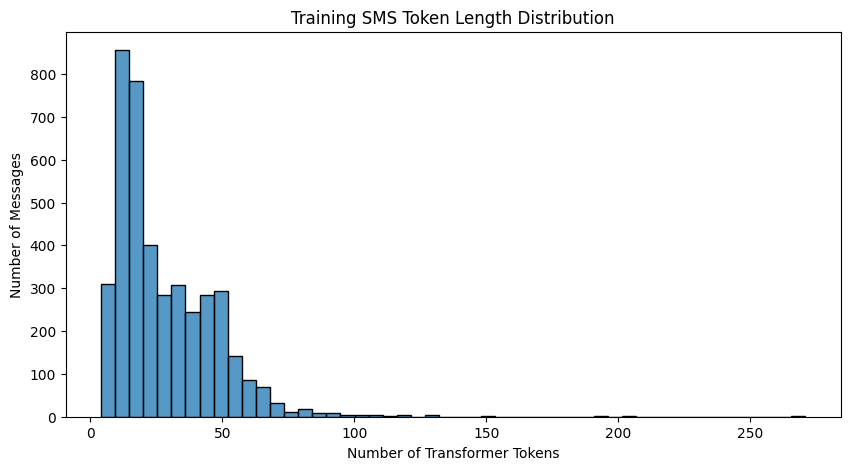

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    train_token_lengths,
    bins=50
)

plt.title("Training SMS Token Length Distribution")
plt.xlabel("Number of Transformer Tokens")
plt.ylabel("Number of Messages")

plt.show()

In [ ]:
print("Messages over 64 tokens:",
      sum(length > 64 for length in train_token_lengths))

print("Messages over 128 tokens:",
      sum(length > 128 for length in train_token_lengths))

print("Messages over 256 tokens:",
      sum(length > 256 for length in train_token_lengths))

Messages over 64 tokens: 149
Messages over 128 tokens: 6
Messages over 256 tokens: 1


**Conclusion:** The vast majority of training messages are short. Only 149 messages exceed 64 tokens, while only 6 of the 4,162 training messages exceed 128 tokens. Therefore, a maximum sequence length of **128 tokens** is selected. This preserves nearly all SMS content while reducing unnecessary computation and memory usage during Transformer fine-tuning.

## 5. Hugging Face Dataset Preparation

The train, validation, and test splits are converted to Hugging Face `Dataset` objects before tokenization.

In [ ]:
from datasets import Dataset

In [ ]:
train_df = pd.DataFrame({
    "text": X_train.reset_index(drop=True),
    "label": y_train_ids.reset_index(drop=True)
})

val_df = pd.DataFrame({
    "text": X_val.reset_index(drop=True),
    "label": y_val_ids.reset_index(drop=True)
})

test_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "label": y_test_ids.reset_index(drop=True)
})

In [ ]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 4162
})
Dataset({
    features: ['text', 'label'],
    num_rows: 892
})
Dataset({
    features: ['text', 'label'],
    num_rows: 893
})


### 5.1 Tokenize the Dataset

A maximum sequence length of 128 tokens is applied based on the token-length analysis above.

In [ ]:
MAX_LENGTH = 128

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [ ]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/4162 [00:00<?, ? examples/s]

Map:   0%|          | 0/892 [00:00<?, ? examples/s]

Map:   0%|          | 0/893 [00:00<?, ? examples/s]

### 5.2 Dynamic Padding

Dynamic padding pads each batch only to the longest sequence in that batch, reducing unnecessary computation compared with padding every SMS to 128 tokens.

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

## 6. Baseline Multilingual DistilBERT

A pretrained multilingual DistilBERT model is adapted for three-class sequence classification using the AmanLeb labels: `ham`, `spam`, and `smishing`.

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  542MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
print("Number of labels:", model.config.num_labels)
print("ID → label:", model.config.id2label)
print("Label → ID:", model.config.label2id)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Number of labels: 3
ID → label: {0: 'ham', 1: 'spam', 2: 'smishing'}
Label → ID: {'ham': 0, 'spam': 1, 'smishing': 2}
Total parameters: 135,326,979
Trainable parameters: 135,326,979


In [ ]:
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

### 6.1 Fine-Tuning Configuration and Training

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./amanleb_transformer_baseline",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=1,

    fp16=True,

    logging_strategy="steps",
    logging_steps=50,

    report_to="none",

    seed=42
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    data_collator=data_collator,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.181525,0.184312,0.927130,0.773767,0.712377,0.700128
2,0.116262,0.128082,0.956278,0.869485,0.845406,0.856725
3,0.094747,0.128920,0.955157,0.852522,0.848033,0.850102


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=783, training_loss=0.15102990833735558, metrics={'train_runtime': 109.5407, 'train_samples_per_second': 113.985, 'train_steps_per_second': 7.148, 'total_flos': 215463618685548.0, 'train_loss': 0.15102990833735558, 'epoch': 3.0})

### 6.2 Validation Evaluation

In [ ]:
val_output = trainer.predict(tokenized_val)

val_logits = val_output.predictions
transformer_val_predictions = np.argmax(
    val_logits,
    axis=-1
)

In [ ]:
print(
    classification_report(
        y_val_ids,
        transformer_val_predictions,
        target_names=[
            "ham",
            "spam",
            "smishing"
        ],
        digits=3
    )
)

              precision    recall  f1-score   support

         ham      0.986     0.999     0.992       725
        spam      0.740     0.740     0.740        73
    smishing      0.882     0.798     0.838        94

    accuracy                          0.956       892
   macro avg      0.869     0.845     0.857       892
weighted avg      0.955     0.956     0.955       892



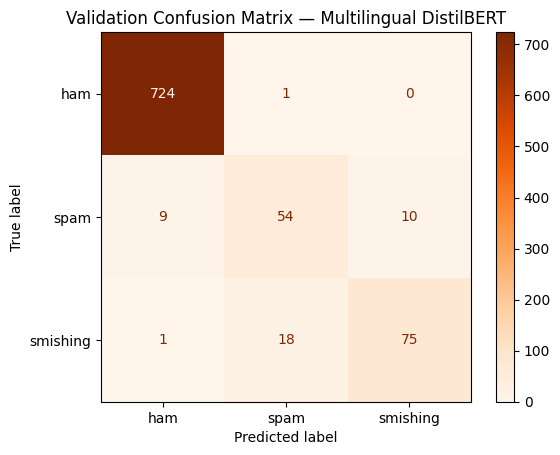

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_val_ids,
    transformer_val_predictions,
    display_labels=[
        "ham",
        "spam",
        "smishing"
    ],
    cmap="Oranges"
)

plt.title(
    "Validation Confusion Matrix — Multilingual DistilBERT"
)

plt.show()

In [ ]:
transformer_suspicious_as_ham = (
    ((y_val_ids == 1) | (y_val_ids == 2)) &
    (transformer_val_predictions == 0)
).sum()

print(
    "Suspicious messages predicted as Ham:",
    transformer_suspicious_as_ham
)

Suspicious messages predicted as Ham: 10


### 6.3 Fine-Tuning Observation

The multilingual DistilBERT baseline reached its strongest validation performance after the second epoch, achieving approximately **96.19% accuracy** and a **0.877 macro F1-score**.

Although the training loss continued to decrease during the third epoch, validation macro F1 decreased from 0.877 to 0.867. This indicates that additional fitting to the training data did not improve generalization and suggests the beginning of overfitting.

Because model selection was configured using validation macro F1, the epoch-2 checkpoint was automatically restored as the best model.

Interestingly, the Transformer baseline does not outperform the class-weighted TF-IDF + Logistic Regression model on the current dataset. This demonstrates that a larger neural model is not automatically superior and motivates further analysis of class-specific performance before modifying the Transformer.

### 6.4 Transformer Baseline Error Analysis

The Transformer baseline achieved a validation accuracy of **96.19%** and a macro F1-score of **0.877**.

The confusion matrix reveals that only **8 suspicious messages were incorrectly classified as Ham**, consisting of 7 Spam messages and only 1 Smishing message. This is slightly better than the class-weighted Logistic Regression model on the same safety-oriented metric.

Most Transformer errors occur between the two suspicious classes. Sixteen Smishing messages were classified as Spam, while eight Spam messages were classified as Smishing. Therefore, the Transformer appears effective at separating suspicious messages from legitimate Ham messages but has more difficulty distinguishing Spam from Smishing.

Although the class-weighted Logistic Regression model currently achieves a higher overall macro F1-score, the Transformer baseline demonstrates promising behavior for the safety-oriented objective of AmanLeb.

## 7. Class-Weighted Multilingual DistilBERT

Because the dataset is imbalanced, balanced class weights are computed from the training split and used in a weighted cross-entropy loss. A fresh pretrained model is fine-tuned so the comparison with the unweighted baseline remains fair.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_ids.to_numpy()
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class weights:", class_weights)

Class weights: tensor([0.4101, 4.0684, 3.1674])


In [ ]:
import torch.nn.functional as F

def weighted_loss(outputs, labels, num_items_in_batch=None):
    logits = outputs.logits

    weights = class_weights.to(logits.device)

    return F.cross_entropy(
        logits,
        labels,
        weight=weights
    )

In [ ]:
weighted_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
weighted_training_args = TrainingArguments(
    output_dir="./amanleb_transformer_weighted",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=1,

    fp16=True,

    logging_strategy="steps",
    logging_steps=50,

    report_to="none",

    seed=42
)

In [ ]:
weighted_trainer = Trainer(
    model=weighted_model,
    args=weighted_training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    data_collator=data_collator,
    processing_class=tokenizer,

    compute_metrics=compute_metrics,
    compute_loss_func=weighted_loss
)

In [ ]:
weighted_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.401006,0.384170,0.957399,0.868107,0.850051,0.854064
2,0.366552,0.403076,0.960762,0.873844,0.878057,0.874513
3,0.214334,0.399543,0.968610,0.902049,0.902879,0.902380


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=783, training_loss=0.35780036982296376, metrics={'train_runtime': 128.0923, 'train_samples_per_second': 97.477, 'train_steps_per_second': 6.113, 'total_flos': 215463618685548.0, 'train_loss': 0.35780036982296376, 'epoch': 3.0})

### 7.1 Validation Evaluation

In [ ]:
weighted_val_output = weighted_trainer.predict(tokenized_val)

weighted_val_logits = weighted_val_output.predictions

weighted_val_predictions = np.argmax(
    weighted_val_logits,
    axis=-1
)

In [ ]:
print(
    classification_report(
        y_val_ids,
        weighted_val_predictions,
        target_names=[
            "ham",
            "spam",
            "smishing"
        ],
        digits=3
    )
)

              precision    recall  f1-score   support

         ham      0.993     0.993     0.993       725
        spam      0.800     0.822     0.811        73
    smishing      0.913     0.894     0.903        94

    accuracy                          0.969       892
   macro avg      0.902     0.903     0.902       892
weighted avg      0.969     0.969     0.969       892



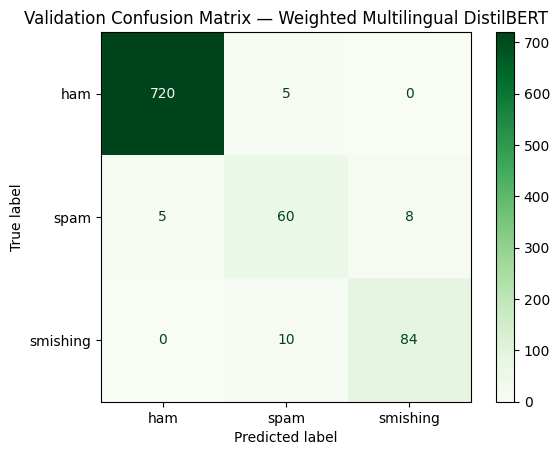

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_val_ids,
    weighted_val_predictions,
    display_labels=[
        "ham",
        "spam",
        "smishing"
    ],
    cmap="Greens"
)

plt.title(
    "Validation Confusion Matrix — Weighted Multilingual DistilBERT"
)

plt.show()

In [ ]:
weighted_suspicious_as_ham = (
    ((y_val_ids == 1) | (y_val_ids == 2)) &
    (weighted_val_predictions == 0)
).sum()

print(
    "Suspicious messages predicted as Ham:",
    weighted_suspicious_as_ham
)

Suspicious messages predicted as Ham: 5


### 7.2 Weighted Transformer Fine-Tuning Observation

Introducing weighted cross-entropy substantially improved the multilingual DistilBERT classifier. The best validation performance was obtained after the third epoch, reaching approximately **96.86% accuracy**, **0.903 macro recall**, and a **0.902 macro F1-score**.

This exceeds both the unweighted Transformer baseline and the class-weighted TF-IDF + Logistic Regression model on validation macro F1. The improvement supports the hypothesis that class imbalance affected the Transformer training process and that assigning greater importance to minority-class errors produces a more balanced classifier.

Unlike the unweighted Transformer, whose validation macro F1 decreased during the third epoch, the weighted model continued improving across all three epochs. Therefore, the third-epoch checkpoint is selected as the preferred Transformer model.

### 7.3 Validation Conclusion and Model Selection

The class-weighted multilingual DistilBERT model produced the strongest validation performance among the evaluated AmanLeb models.

The model achieved **96.86% validation accuracy** and a **0.902 macro F1-score**, outperforming both the unweighted Transformer baseline and the class-weighted TF-IDF + Logistic Regression classifier.

Class-specific performance was also well balanced. Ham achieved an F1-score of 0.993, Spam achieved 0.811, and Smishing achieved 0.903.

From the AmanLeb safety perspective, the confusion matrix is particularly encouraging. None of the 94 Smishing validation messages were classified as Ham. Eighty-four were correctly identified as Smishing, while ten were classified as Spam and therefore still recognized as suspicious.

The total number of suspicious messages incorrectly classified as Ham decreased to only **5**, compared with 8 for the unweighted Transformer and 10 for the class-weighted Logistic Regression model.

These results support the use of weighted cross-entropy for the imbalanced AmanLeb dataset. Based on validation macro F1 and safety-oriented error analysis, the weighted multilingual DistilBERT model is selected as the final Transformer classifier.

## 8. Save the Selected Transformer

`load_best_model_at_end=True` and `metric_for_best_model="macro_f1"` ensure that `weighted_trainer.model` contains the validation-selected model after training. The selected model and tokenizer are therefore saved directly, without manually searching for a checkpoint directory.

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

FINAL_MODEL_PATH = Path(
    "/content/drive/MyDrive/AmanLeb/amanleb_final_transformer"
)

FINAL_MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

weighted_trainer.model.save_pretrained(
    FINAL_MODEL_PATH
)

tokenizer.save_pretrained(
    FINAL_MODEL_PATH
)

print("Final AmanLeb Transformer saved to:")
print(FINAL_MODEL_PATH)

## 9. Final Evaluation on the Untouched Test Set

The weighted Transformer was selected using validation performance before the test set was used for final evaluation. The following results therefore measure performance on the held-out 893-message test split.

In [ ]:
weighted_test_output = weighted_trainer.predict(
    tokenized_test
)

weighted_test_logits = weighted_test_output.predictions

weighted_test_predictions = np.argmax(
    weighted_test_logits,
    axis=-1
)

### 9.1 Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_ids,
        weighted_test_predictions,
        target_names=[
            "ham",
            "spam",
            "smishing"
        ],
        digits=3
    )
)

              precision    recall  f1-score   support

         ham      0.997     1.000     0.999       726
        spam      0.836     0.836     0.836        73
    smishing      0.891     0.872     0.882        94

    accuracy                          0.973       893
   macro avg      0.908     0.903     0.905       893
weighted avg      0.973     0.973     0.973       893



### 9.2 Confusion Matrix

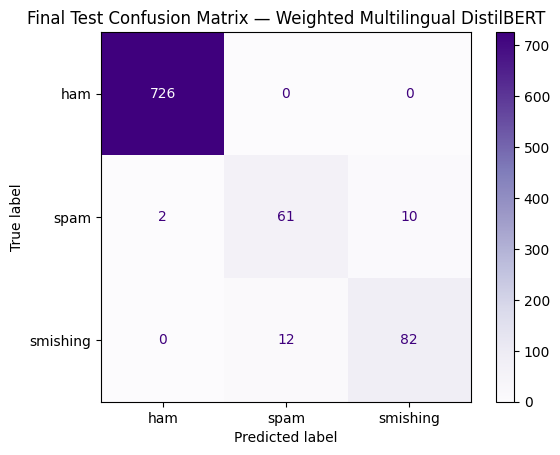

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_ids,
    weighted_test_predictions,
    display_labels=[
        "ham",
        "spam",
        "smishing"
    ],
    cmap="Purples"
)

plt.title(
    "Final Test Confusion Matrix — Weighted Multilingual DistilBERT"
)

plt.show()

### 9.3 Safety-Oriented Error Metrics

In [ ]:
weighted_test_suspicious_as_ham = (
    ((y_test_ids == 1) | (y_test_ids == 2)) &
    (weighted_test_predictions == 0)
).sum()

print(
    "Suspicious messages predicted as Ham:",
    weighted_test_suspicious_as_ham
)

Suspicious messages predicted as Ham: 2


In [ ]:
test_smishing_as_ham = (
    (y_test_ids == 2) &
    (weighted_test_predictions == 0)
).sum()

print(
    "Smishing messages predicted as Ham:",
    test_smishing_as_ham
)

Smishing messages predicted as Ham: 0


## 10. Final Transformer Classifier Conclusion

This notebook developed and evaluated the Transformer-based classification stage of **AmanLeb**.

A pretrained multilingual **DistilBERT** model was fine-tuned to classify SMS messages into three classes: `ham`, `spam`, and `smishing`. The same 70/15/15 stratified train-validation-test split used for the classical machine learning experiment was preserved to allow a fair comparison between the approaches.

Token-length analysis showed that almost all SMS messages contained fewer than 128 Transformer tokens, so a maximum sequence length of **128 tokens** was selected to preserve nearly all message content while keeping computation efficient.

The initial unweighted Transformer achieved strong performance but still showed weaker performance on the minority Spam and Smishing classes. Based on this observation and the known class imbalance in the dataset, a second Transformer was trained using **weighted cross-entropy loss**, assigning greater importance to errors involving the minority classes.

The weighted multilingual DistilBERT model achieved the strongest validation performance, with approximately **96.86% accuracy** and a **0.902 macro F1-score**, and was therefore selected as the final Transformer classifier before the test set was accessed.

On the previously untouched test set of **893 SMS messages**, the final model achieved:

* **Accuracy:** 97.3%
* **Macro Precision:** 0.908
* **Macro Recall:** 0.903
* **Macro F1-score:** 0.905

Class-specific F1-scores were **0.999 for Ham**, **0.836 for Spam**, and **0.882 for Smishing**.

From the AmanLeb safety perspective, the confusion matrix produced an especially encouraging result. Of the **94 Smishing messages** in the test set, **none were incorrectly classified as Ham**. Eighty-two were correctly classified as Smishing, while twelve were classified as Spam and therefore still recognized as suspicious. Across both suspicious classes, only **2 messages were incorrectly classified as Ham**, and both belonged to the Spam class.

The Transformer also improved upon the final classical machine learning baseline. The class-weighted TF-IDF + Logistic Regression model achieved **96.08% test accuracy**, a **0.884 macro F1-score**, and 5 suspicious-to-Ham errors. The weighted multilingual DistilBERT model improved these results to **97.3% accuracy**, a **0.905 macro F1-score**, and only 2 suspicious-to-Ham errors.

These results demonstrate that contextual Transformer representations and class-weighted training provide a measurable improvement over the classical TF-IDF approach on the current dataset.

However, these results should not be interpreted as proof that AmanLeb will never miss a real-world scam. The current dataset does not fully represent Lebanese, Arabic, French, Arabizi, mixed-language, or future scam patterns. Further Lebanon-specific evaluation is therefore necessary before making real-world deployment claims.

The **weighted multilingual DistilBERT model is selected as the final AmanLeb classification engine**.

The next stage of the project extends this classifier with **Retrieval-Augmented Generation (RAG)** so that AmanLeb can move beyond predicting a label and retrieve trusted information to explain suspicious messages and provide grounded safety guidance.
